# TITANIC DATASET

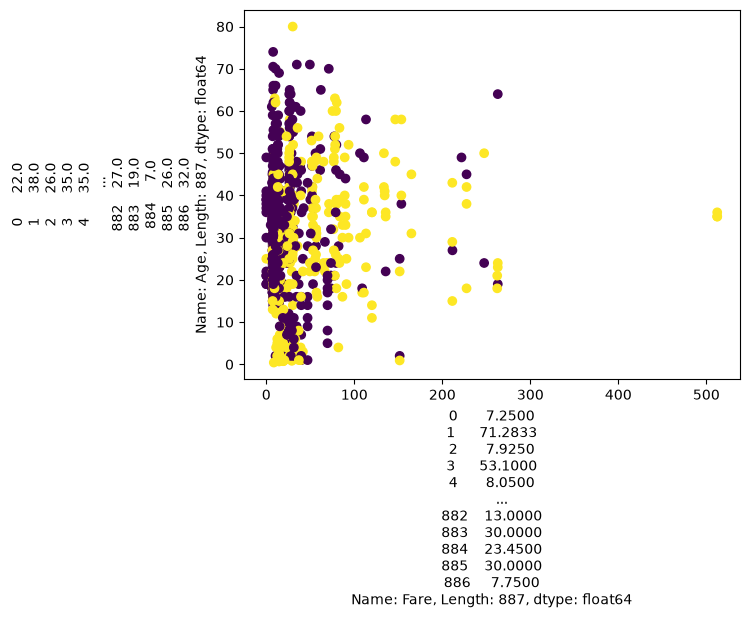

In [13]:
from pyexpat import features

# Classification Graphically

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from fontTools.merge import cmap

df = pd.read_csv("titanic.csv")

plt.xlabel(df['Fare'])
plt.ylabel(df['Age'])

plt.scatter(df["Fare"], df["Age"], c=df["Survived"], cmap='viridis')

plt.show()


In [14]:
# Linear Regression Model

# 1. Prepare Data with Pandas

df['Male'] = df['Sex'] == "male"

X = df[['Pclass', 'Male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values[:20]
Y = df['Survived'].values[:20]

print(X)
print(Y)

[[3 True 22.0 1 0 7.25]
 [1 False 38.0 1 0 71.2833]
 [3 False 26.0 0 0 7.925]
 [1 False 35.0 1 0 53.1]
 [3 True 35.0 0 0 8.05]
 [3 True 27.0 0 0 8.4583]
 [1 True 54.0 0 0 51.8625]
 [3 True 2.0 3 1 21.075]
 [3 False 27.0 0 2 11.1333]
 [2 False 14.0 1 0 30.0708]
 [3 False 4.0 1 1 16.7]
 [1 False 58.0 0 0 26.55]
 [3 True 20.0 0 0 8.05]
 [3 True 39.0 1 5 31.275]
 [3 False 14.0 0 0 7.8542]
 [2 False 55.0 0 0 16.0]
 [3 True 2.0 4 1 29.125]
 [2 True 23.0 0 0 13.0]
 [3 False 31.0 1 0 18.0]
 [3 False 22.0 0 0 7.225]]
[0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1]


[[ 0.01615934 -0.0154909 ]] [-0.51035265]


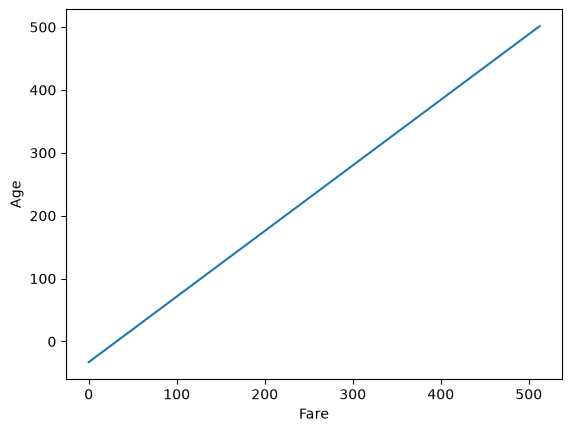

In [15]:
# Building a Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

X = df[['Fare', 'Age']].values
y = df['Survived'].values

model.fit(X, y)

print(model.coef_, model.intercept_) # Coefficients x,y and intercept c. From ax+by+c = 0

plt.xlabel('Fare')
plt.ylabel('Age')

# plt.scatter(df['Fare'], df['Age'], c=df['Survived'])
# plt.plot((df['Fare']*model.coef_[0][1]), (df['Age']*model.coef_[0][0]))
# plt.show()

fare_vals = np.linspace(df['Fare'].min(), df['Fare'].max(), 100) #Return evenly spaced numbers / datapoints over a specified interval.
# print(fare_vals)
age_vals = -(0.0161594*fare_vals - 0.51037152) / -0.01549065 #Equivalent to y=-(ax-c)/-b
plt.plot(fare_vals, age_vals)
plt.show()


In [16]:
### Make Predictions with the Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

X = df[['Pclass', 'Male', 'Age', 'Siblings/Spouses', 'Parents/Children', 'Fare']].values
y = df['Survived'].values

model.fit(X, y)
print(model.predict([[3, True, 22.0, 1, 0, 7.25]])) # user-inputted data points
print(model.predict(X[:6])) # from first 6 rows of data array
print(y[:6]) # compare to first 6 values of target array
# Excellent it got all 6 correct!

[0]
[0 1 1 1 0 0]
[0 1 1 1 0 0]


In [17]:
### Score the Model

y_pred = model.predict(X)
print((y == y_pred).sum()) # only 714 out of 887 datapoints are correct predictions
print((y == y_pred).sum() / y.shape[0]*100) # compute accuracy score, we get it's 80.4%
print(model.score(X,y)) # use score(X,y) method to compute the accuracy score


714
80.49605411499437
0.8049605411499436


# BREAST CANCER DATASET

In [18]:
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()

print(cancer_data.keys())
print(cancer_data['DESCR'])

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 f

In [26]:
### Loading the Data into Pandas

print(cancer_data['data'].shape) # data entries = 569, features = 30

### now put the data into Pandas DataFrame to make more human-readable
### we will want column names which will be stored with 'feature_names' key

print(cancer_data['feature_names']) # print all feature names

df = pd.DataFrame(cancer_data['data'], columns=cancer_data['feature_names'])
print(df.head()) # print the DataFrame

## Now we put the target data as well in the Pandas DataFrame

print(cancer_data['target'])
print(cancer_data['target'].shape)

print(cancer_data['target_names']) # returns the target names used in this dataset ['malignant' 'benign']

df['target'] = cancer_data['target']

print(df.head()) # you will notice that now we have 31 columns

(569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0

In [42]:
### Now let's Build a Logistic Regression Model from the Breast Cancer Dataset

# 1. Build feature matrix X, and target array y

X = df[cancer_data.feature_names].values
y = df['target'].values

# 2. Let's create a Logistic Regression object

# model = LogisticRegression() # When we run this code we get a Convergence Warning. This means that the model needs more time to find the optimal solution.
# model.fit(X, y)

# One option is to increase the number of iterations. Which is why we decided to switch to a different solver, 'liblinear'.
model = LogisticRegression(solver='liblinear')
model.fit(X, y)

model.predict(X[:100])

# Then how much is the model accurate?
accuracy = model.score(X, y)
print("The model has: " + str(accuracy*100) + "% accuracy.")


The model is: 95.95782073813707% accurate.
